---
# STEP 6 영향 분석 
## 회귀분석 + FPI 구간별 성과 비교

## 수정 사항
- FPI 기준 반경: 기존 100m → **300m** (Shift 정규화 적용 후 민감도 분석 결과 반영)
- 임계거리 변경 근거: 별점과 감성점수 두 종속변수 모두 p<0.05인 최소 반경이 300m

## 분석 개요

| 단계 | 내용 |
|---|---|
| STEP 6-0 | 통제변수 선정 |
| STEP 6-1 | 다중회귀분석 (OLS) — 별점, 감성점수 |
| STEP 6-2 | FPI 구간 분류 (NP / LP / HP) |
| STEP 6-3 | 구간별 성과 비교 및 통계 검정 (ANOVA + Tukey) |
| STEP 6-4 | 시각화 |

**입력 데이터**
- `biz_sentiment_with_fpi.csv`: 업체별 FPI + 감성점수 (다중회귀용)
- `biz_indie_with_groups.csv`: 구간 분류 완료 데이터 (ANOVA용)

**종속변수**
- 별점 (stars)
- 감성점수 (tfidf_sentiment)

**독립변수**
- fpi_300m

**통제변수**
- review_count (매장 규모)
- neighborhood 더미 (상권 특성)

---
## STEP 6-0. 통제변수 선정

회귀분석 전 통제변수를 이론적으로 검토하고 확정한다.

**좋은 통제변수의 조건 (두 가지 동시 충족)**
1. 종속변수(별점/감성점수)에 영향을 미치는 변수
2. 독립변수(FPI)와 상관관계가 있는 변수

두 조건을 모두 만족하지 못하면 통제변수로 넣을 이유가 없다.

### 6-0-1. 데이터 로드 및 기본 확인

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings('ignore')

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

PATH_to_data = "../results"
PATH_to_save = "../results"

# 데이터 로드
df_full = pd.read_csv(f"{PATH_to_data}/biz_sentiment_with_fpi.csv")
indie_df = df_full[df_full['is_franchise'] == False].copy()

print(f"독립 브랜드 수: {len(indie_df):,}개")
print(f"\n컬럼 목록:")
print(indie_df.columns.tolist())

독립 브랜드 수: 4,818개

컬럼 목록:
['business_id', 'name', 'neighborhood', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'categories', 'name_clean', 'is_franchise', 'type', 'tfidf_sentiment', 'vader_sentiment', 'fpi_100m', 'fpi_200m', 'fpi_300m', 'fpi_500m']


### 6-0-2. categories 컬럼 확인

업종 세부 카테고리가 통제변수로 적합한지 확인한다.
Restaurants 안에서도 Fast Food, Pizza, Mexican 등 세부 업종에 따라
별점 기준과 프랜차이즈 비율이 다를 수 있어 통제가 필요할 수 있다.

In [4]:
# categories 컬럼 확인
print("=== categories 샘플 ===")
print(indie_df['categories'].head(10).tolist())
print(f"\n결측치: {indie_df['categories'].isna().sum()}개")

# 카테고리 분해
cats = indie_df['categories'].dropna().str.split(';').explode().str.strip()
cat_counts = cats.value_counts()

print(f"\n=== 전체 세부 카테고리 수: {len(cat_counts)}개 ===")
print(f"\n상위 30개:")
print(cat_counts.head(30))

=== categories 샘플 ===
['Nightlife;Bars;Barbeque;Sports Bars;American (New);Restaurants', 'Arcades;Arts & Entertainment;Gastropubs;Restaurants;American (New)', 'Italian;Restaurants', 'Restaurants;Cafes;American (New);Bars;Nightlife;Wine Bars', 'Restaurants;American (Traditional)', 'Seafood;Italian;Pizza;Restaurants', 'Karaoke;Bars;Mexican;Restaurants;Nightlife;Dance Clubs', 'Restaurants;Thai', 'Dance Clubs;Nightlife;Restaurants;Barbeque;American (Traditional)', 'Restaurants;American (Traditional);Food;Coffee & Tea;Salad;Breakfast & Brunch']

결측치: 0개

=== 전체 세부 카테고리 수: 390개 ===

상위 30개:
categories
Restaurants                  4818
Food                         1062
Nightlife                     754
Bars                          709
American (Traditional)        635
Mexican                       581
American (New)                504
Pizza                         499
Chinese                       389
Italian                       379
Breakfast & Brunch            372
Sandwiches             

### 6-0-3. 통제변수 후보 검토

후보 변수별로 두 가지 조건을 확인한다.
1. 종속변수(별점/감성점수)와의 상관관계
2. 독립변수(FPI)와의 상관관계

In [5]:
indie_df['log_review'] = np.log(indie_df['review_count'] + 1)

# 후보 변수들과 종속변수/FPI 간 상관관계
candidates = ['log_review', 'is_open', 'fpi_300m']
targets = ['stars', 'tfidf_sentiment']

print("=== 후보 변수 × 종속변수 상관계수 ===")
corr_target = indie_df[candidates + targets].corr()[targets].loc[candidates]
print(corr_target.round(4))

print("\n=== 후보 변수 × FPI 상관계수 ===")
corr_fpi = indie_df[candidates].corr()[['fpi_300m']].drop('fpi_300m')
print(corr_fpi.round(4))

=== 후보 변수 × 종속변수 상관계수 ===
             stars  tfidf_sentiment
log_review  0.1585           0.1758
is_open     0.1028           0.0649
fpi_300m   -0.0850          -0.0333

=== 후보 변수 × FPI 상관계수 ===
            fpi_300m
log_review    0.0741
is_open      -0.0130


In [6]:
# is_open 분포 확인
print("=== is_open 분포 ===")
print(indie_df['is_open'].value_counts())
print(f"\n폐업 업체 비율: {(indie_df['is_open']==0).sum()/len(indie_df)*100:.1f}%")

# neighborhood 분포 확인
print("\n=== neighborhood 상위 20개 ===")
print(indie_df['neighborhood'].value_counts().head(20))
print(f"\n결측치: {indie_df['neighborhood'].isna().sum()}개")
print(f"고유값 수: {indie_df['neighborhood'].nunique()}개")

=== is_open 분포 ===
is_open
1    3017
0    1801
Name: count, dtype: int64

폐업 업체 비율: 37.4%

=== neighborhood 상위 20개 ===
neighborhood
The Strip          790
Westside           538
Southeast          506
Eastside           445
Spring Valley      383
Downtown           343
Chinatown          313
Southwest          181
Northwest          158
Sunrise            116
Summerlin          106
Centennial         106
South Summerlin     71
University          69
The Lakes           21
Anthem              10
Name: count, dtype: int64

결측치: 662개
고유값 수: 16개


In [7]:
# neighborhood별 평균 별점 확인 (상권 특성 차이 확인)
print("=== neighborhood별 평균 별점 (상위 15개) ===")
nb_stars = indie_df.groupby('neighborhood')['stars'].agg(['mean', 'count'])\
                   .sort_values('count', ascending=False).head(15)
print(nb_stars.round(2))

print("\n=== neighborhood별 평균 FPI (상위 15개) ===")
nb_fpi = indie_df.groupby('neighborhood')['fpi_300m'].agg(['mean', 'count'])\
                 .sort_values('count', ascending=False).head(15)
print(nb_fpi.round(4))

=== neighborhood별 평균 별점 (상위 15개) ===
                 mean  count
neighborhood                
The Strip        3.42    790
Westside         3.76    538
Southeast        3.57    506
Eastside         3.59    445
Spring Valley    3.80    383
Downtown         3.76    343
Chinatown        3.73    313
Southwest        3.65    181
Northwest        3.58    158
Sunrise          3.58    116
Centennial       3.60    106
Summerlin        3.64    106
South Summerlin  3.55     71
University       3.62     69
The Lakes        3.86     21

=== neighborhood별 평균 FPI (상위 15개) ===
                   mean  count
neighborhood                  
The Strip        3.8703    790
Westside         1.7397    538
Southeast        2.4461    506
Eastside         1.5433    445
Spring Valley    2.8825    383
Downtown         1.2706    343
Chinatown        0.7236    313
Southwest        1.5071    181
Northwest        2.2393    158
Sunrise          1.5888    116
Centennial       2.5947    106
Summerlin        2.1619    1

### 6-0-4. 통제변수 최종 확정

**검토 결과 요약**

| 변수 | 별점 상관 | 감성점수 상관 | FPI 상관 | 채택 여부 |
|---|---|---|---|---|
| log(review_count) | 0.1585 | 0.1758 | 0.0741 |  통제변수 채택 |
| neighborhood 더미 | 상권별 별점 차이 뚜렷 (3.42~3.86) | - | FPI 차이 뚜렷 (0.72~7.94) |  통제변수 채택 |
| is_open | 0.1028 | 0.0649 | -0.013 |  FPI 상관 없음 → 필터링만 |
| categories | - | - | - |  390개 더미 → 모델 불안정 |

**최종 확정**
- 사전 필터링: `is_open = 1` (영업 중인 업체만, 폐업 37.4% 제외)
- 통제변수 1: `log(review_count)` — 매장 규모
- 통제변수 2: `neighborhood` 더미 — 상권 특성 (결측치 → Unknown 처리)

**선정 근거**
- log(review_count): 리뷰가 많을수록 별점이 안정적으로 높아지는 경향이 있으며, 규모가 큰 매장일수록 상권 밀집지에 위치해 FPI와도 상관이 있음
- neighborhood: The Strip(평균 별점 3.42, FPI 3.87) vs Chinatown(FPI 0.72)처럼 상권에 따라 별점과 FPI 모두 뚜렷한 차이를 보여 교란변수로 작용할 가능성이 높음
- is_open: 종속변수와 상관이 있으나 FPI와 거의 무관(-0.013)해 통제변수 조건 미충족. 대신 폐업 업체를 사전 필터링하여 분석 품질을 높임
- categories: 390개 세부 카테고리로 더미 변수가 과도하게 많아져 모델 불안정 우려. neighborhood로 상권 특성을 충분히 통제

### 6-0-5. 분석 데이터 준비

통제변수 확정 기준에 따라 분석 데이터를 전처리한다.

In [8]:
# 1. 영업 중인 업체만 필터링
indie_df = indie_df[indie_df['is_open'] == 1].copy()
print(f"영업 중인 독립 브랜드: {len(indie_df):,}개")

# 2. log(review_count) 생성
indie_df['log_review'] = np.log(indie_df['review_count'] + 1)

# 3. neighborhood 결측치 처리
indie_df['neighborhood'] = indie_df['neighborhood'].fillna('Unknown')
print(f"\nneighborhood 고유값 수: {indie_df['neighborhood'].nunique()}개")
print(indie_df['neighborhood'].value_counts())

# 4. neighborhood 더미 변수 생성
nb_dummies = pd.get_dummies(indie_df['neighborhood'], prefix='nb', drop_first=True)
indie_df = pd.concat([indie_df.reset_index(drop=True),
                      nb_dummies.reset_index(drop=True)], axis=1)
dummy_cols = [c for c in indie_df.columns if c.startswith('nb_')]

print(f"\n더미 변수 수: {len(dummy_cols)}개")
print(f"최종 분석 데이터: {len(indie_df):,}행")

영업 중인 독립 브랜드: 3,017개

neighborhood 고유값 수: 17개
neighborhood
The Strip          550
Unknown            410
Southeast          317
Westside           303
Eastside           275
Spring Valley      222
Downtown           217
Chinatown          176
Southwest          126
Northwest           99
Sunrise             86
Centennial          73
Summerlin           63
South Summerlin     53
University          32
The Lakes           11
Anthem               4
Name: count, dtype: int64

더미 변수 수: 16개
최종 분석 데이터: 3,017행


---
## STEP 6-1. 다중회귀분석 (OLS)

**모델 설계**

$$\text{별점} = \beta_0 + \beta_1 \cdot FPI_{300m} + \beta_2 \cdot \log(\text{리뷰수}+1) + \sum \beta_k \cdot \text{neighborhood}_k + \epsilon$$

$$\text{감성점수} = \beta_0 + \beta_1 \cdot FPI_{300m} + \beta_2 \cdot \log(\text{리뷰수}+1) + \sum \beta_k \cdot \text{neighborhood}_k + \epsilon$$

통제변수를 투입해 FPI의 **순수한** 영향만 추출한다.

In [9]:
# 독립변수 행렬 구성
X = indie_df[['fpi_300m', 'log_review'] + dummy_cols]
X = sm.add_constant(X)

print(f"독립변수 구성: FPI + log_review + neighborhood 더미 {len(dummy_cols)}개")
print(f"독립변수 총 수: {X.shape[1]}개")
print(f"관측치 수: {X.shape[0]:,}개")

독립변수 구성: FPI + log_review + neighborhood 더미 16개
독립변수 총 수: 19개
관측치 수: 3,017개


In [10]:
# 독립변수 행렬에 object 타입 컬럼이 섞여 오류발생 -> 더미 변수가 bool 타입으로 생성됐을 가능성이 높음
print(X.dtypes.value_counts())
print("\nobject 타입 컬럼:")
print(X.dtypes[X.dtypes == 'object'])
print("\nbool 타입 컬럼:")
print(X.dtypes[X.dtypes == 'bool'])

bool       16
float64     3
Name: count, dtype: int64

object 타입 컬럼:
Series([], dtype: object)

bool 타입 컬럼:
nb_Centennial         bool
nb_Chinatown          bool
nb_Downtown           bool
nb_Eastside           bool
nb_Northwest          bool
nb_South Summerlin    bool
nb_Southeast          bool
nb_Southwest          bool
nb_Spring Valley      bool
nb_Summerlin          bool
nb_Sunrise            bool
nb_The Lakes          bool
nb_The Strip          bool
nb_University         bool
nb_Unknown            bool
nb_Westside           bool
dtype: object


In [11]:
# bool을 int로 변환하여 독립변수 행렬 구성
X = indie_df[['fpi_300m', 'log_review'] + dummy_cols].astype(float)
X = sm.add_constant(X)

print(f"독립변수 구성: FPI + log_review + neighborhood 더미 {len(dummy_cols)}개")
print(f"독립변수 총 수: {X.shape[1]}개")
print(f"관측치 수: {X.shape[0]:,}개")
print(f"\ndtype 확인:")
print(X.dtypes.value_counts())

독립변수 구성: FPI + log_review + neighborhood 더미 16개
독립변수 총 수: 19개
관측치 수: 3,017개

dtype 확인:
float64    19
Name: count, dtype: int64


In [12]:
# 모델 1: 별점
print("=" * 60)
print("모델 1 — FPI → 별점(Stars)")
print("=" * 60)

y_stars = indie_df['stars']
model_stars = sm.OLS(y_stars, X).fit()

print(f"\n[FPI 계수]")
print(f"  회귀계수 : {model_stars.params['fpi_300m']:.4f}")
print(f"  P-value  : {model_stars.pvalues['fpi_300m']:.4f}")
print(f"  95% CI   : [{model_stars.conf_int().loc['fpi_300m', 0]:.4f}, "
      f"{model_stars.conf_int().loc['fpi_300m', 1]:.4f}]")
print(f"  유의미   : {' p<0.05' if model_stars.pvalues['fpi_300m'] < 0.05 else '❌ p≥0.05'}")
print(f"\n[모델 전체]")
print(f"  R²       : {model_stars.rsquared:.4f}")
print(f"  Adj R²   : {model_stars.rsquared_adj:.4f}")
print(f"  F-stat   : {model_stars.fvalue:.4f} (p={model_stars.f_pvalue:.4f})")

모델 1 — FPI → 별점(Stars)

[FPI 계수]
  회귀계수 : -0.0119
  P-value  : 0.0370
  95% CI   : [-0.0231, -0.0007]
  유의미   :  p<0.05

[모델 전체]
  R²       : 0.0717
  Adj R²   : 0.0661
  F-stat   : 12.8553 (p=0.0000)


*모델 1 — FPI → 별점*

>- FPI 계수 -0.0119 (p=0.037) → 유의미한 음(-)의 영향
>- "FPI가 1 증가할 때 독립 브랜드 별점이 평균 0.012점 감소"
>- 우리 가설 방향과 일치

*전체 모델 해석*

>- R² 0.0717 → 독립변수들이 별점 분산의 7.2% 설명
>- F-stat p=0.000 → 모델 자체는 유의미
>- R²가 낮은 건 Yelp 별점에 영향을 주는 요인이 워낙 많아서 자연스러운 것으로 해석

In [13]:
# 모델 2: 감성점수
print("=" * 60)
print("모델 2 — FPI → 감성점수(Sentiment)")
print("=" * 60)

y_sent = indie_df['tfidf_sentiment']
model_sent = sm.OLS(y_sent, X).fit()

print(f"\n[FPI 계수]")
print(f"  회귀계수 : {model_sent.params['fpi_300m']:.4f}")
print(f"  P-value  : {model_sent.pvalues['fpi_300m']:.4f}")
print(f"  95% CI   : [{model_sent.conf_int().loc['fpi_300m', 0]:.4f}, "
      f"{model_sent.conf_int().loc['fpi_300m', 1]:.4f}]")
print(f"  유의미   : {' p<0.05' if model_sent.pvalues['fpi_300m'] < 0.05 else ' p≥0.05'}")
print(f"\n[모델 전체]")
print(f"  R²       : {model_sent.rsquared:.4f}")
print(f"  Adj R²   : {model_sent.rsquared_adj:.4f}")
print(f"  F-stat   : {model_sent.fvalue:.4f} (p={model_sent.f_pvalue:.4f})")

모델 2 — FPI → 감성점수(Sentiment)

[FPI 계수]
  회귀계수 : -0.0001
  P-value  : 0.3910
  95% CI   : [-0.0003, 0.0001]
  유의미   :  p≥0.05

[모델 전체]
  R²       : 0.0632
  Adj R²   : 0.0575
  F-stat   : 11.2305 (p=0.0000)


*모델 2 — FPI → 감성점수*

>- FPI 계수 -0.0001 (p=0.391) → 유의미하지 않음
>- 통제변수를 넣은 상태에서 FPI가 감성점수에 미치는 영향은 없음
>- "FPI가 소비자의 수치적 평가(별점)에는 영향을 주지만 텍스트로 표현된 실질적 감성까지는 영향을 못 미친다"

---
## STEP 6-2. FPI 구간 분류

STEP 5에서 저장된 `biz_indie_with_groups.csv`를 불러와 구간별 분석을 진행한다.
단, 회귀분석과 동일하게 **영업 중인 업체(is_open=1)만** 필터링한다.

- **NP (No Pressure)**: fpi_300m = 0
- **LP (Low Pressure)**: fpi_300m > 0 하위 50%
- **HP (High Pressure)**: fpi_300m > 0 상위 50%

In [14]:
indie_groups = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")

# 영업 중인 업체만 필터링 (회귀분석과 동일 기준)
indie_groups = indie_groups[indie_groups['is_open'] == 1].copy()

group_order = ['NP', 'LP', 'HP']
indie_groups['fpi_group'] = pd.Categorical(
    indie_groups['fpi_group'], categories=group_order, ordered=True
)

print("FPI 구간 분포 (영업 중인 업체 기준):")
print(indie_groups['fpi_group'].value_counts())
print(f"\n전체: {len(indie_groups):,}개")
print(f"\n구간별 비율:")
print((indie_groups['fpi_group'].value_counts() / len(indie_groups) * 100).round(1))

FPI 구간 분포 (영업 중인 업체 기준):
fpi_group
HP    1220
LP    1217
NP     580
Name: count, dtype: int64

전체: 3,017개

구간별 비율:
fpi_group
HP    40.4
LP    40.3
NP    19.2
Name: count, dtype: float64


---
## STEP 6-3. 구간별 성과 비교 및 통계 검정

### 분석 순서
1. 구간별 기술통계 (평균, 중앙값, 표준편차)
2. One-way ANOVA: 구간 간 차이의 통계적 유의성 검정
3. Tukey HSD 사후검정: 어느 구간 간 차이가 유의미한지 확인

In [15]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 기술통계
print("=" * 60)
print("구간별 기술통계")
print("=" * 60)
summary = indie_groups.groupby('fpi_group')[['stars', 'tfidf_sentiment']]\
                      .agg(['mean', 'median', 'std', 'count']).round(4)
print(summary)

구간별 기술통계
            stars                      tfidf_sentiment                      
             mean median     std count            mean  median     std count
fpi_group                                                                   
NP         3.8284    4.0  0.7176   580          0.0133  0.0138  0.0135   580
LP         3.6890    4.0  0.6907  1217          0.0124  0.0129  0.0134  1217
HP         3.6061    3.5  0.7091  1220          0.0115  0.0122  0.0136  1220


In [16]:
# ANOVA + Tukey
for label, col in [("별점(Stars)", "stars"),
                   ("감성점수(Sentiment)", "tfidf_sentiment")]:
    print(f"\n{'='*60}")
    print(f"[ANOVA] {label}")
    print(f"{'='*60}")

    groups = [indie_groups[indie_groups['fpi_group'] == g][col].dropna()
              for g in group_order]
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"F-statistic : {f_stat:.4f}")
    print(f"P-value     : {p_val:.4f}")
    print(f"유의미 여부 : {' p<0.05' if p_val < 0.05 else ' p≥0.05'}")

    print(f"\n[Tukey HSD 사후검정]")
    valid = indie_groups[indie_groups[col].notna()]
    tukey = pairwise_tukeyhsd(valid[col], valid['fpi_group'], alpha=0.05)
    print(tukey.summary())


[ANOVA] 별점(Stars)
F-statistic : 19.7245
P-value     : 0.0000
유의미 여부 :  p<0.05

[Tukey HSD 사후검정]
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
    HP     LP   0.0828 0.0103  0.016 0.1497   True
    HP     NP   0.2223    0.0 0.1391 0.3055   True
    LP     NP   0.1395 0.0003 0.0562 0.2227   True
--------------------------------------------------

[ANOVA] 감성점수(Sentiment)
F-statistic : 3.7954
P-value     : 0.0226
유의미 여부 :  p<0.05

[Tukey HSD 사후검정]
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    HP     LP   0.0009 0.2396 -0.0004 0.0022  False
    HP     NP   0.0018 0.0195  0.0002 0.0034   True
    LP     NP   0.0009 0.3435 -0.0006 0.0025  False
---------------------------------------------------


---
## STEP 6-4. 시각화

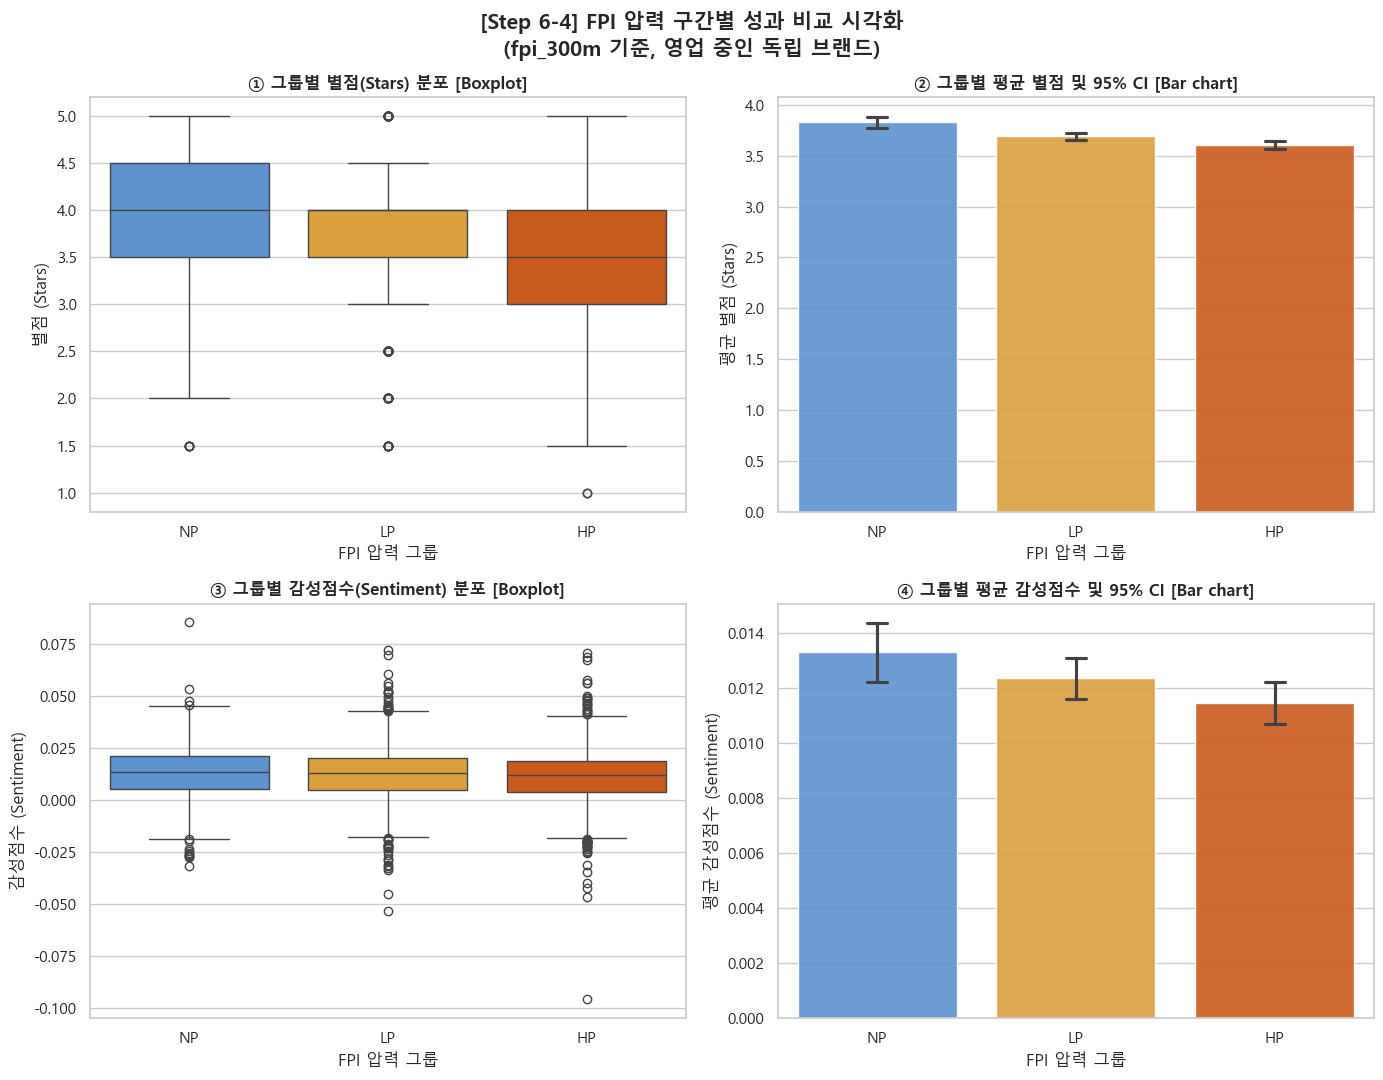

저장 완료: step6_results_300m.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Seaborn 테마를 적용하면서 동시에 한글 폰트와 마이너스 부호 설정을 주입합니다.
sns.set_theme(
    style="whitegrid", 
    rc={
        'font.family': 'Malgun Gothic',
        'axes.unicode_minus': False
    }
)

colors = ['#4a90e2', '#f5a623', '#e65100']

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('[Step 6-4] FPI 압력 구간별 성과 비교 시각화\n(fpi_300m 기준, 영업 중인 독립 브랜드)',
             fontsize=15, fontweight='bold', y=0.98)

# ① 별점 박스플롯
sns.boxplot(ax=axes[0, 0], x='fpi_group', y='stars',
            data=indie_groups, order=group_order, palette=colors)
axes[0, 0].set_title('① 그룹별 별점(Stars) 분포 [Boxplot]',
                      fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('FPI 압력 그룹')
axes[0, 0].set_ylabel('별점 (Stars)')

# ② 별점 바차트
sns.barplot(ax=axes[0, 1], x='fpi_group', y='stars',
            data=indie_groups, order=group_order, palette=colors,
            errorbar=('ci', 95), capsize=0.1, alpha=0.9)
axes[0, 1].set_title('② 그룹별 평균 별점 및 95% CI [Bar chart]',
                      fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('FPI 압력 그룹')
axes[0, 1].set_ylabel('평균 별점 (Stars)')

# ③ 감성점수 박스플롯
sns.boxplot(ax=axes[1, 0], x='fpi_group', y='tfidf_sentiment',
            data=indie_groups, order=group_order, palette=colors)
axes[1, 0].set_title('③ 그룹별 감성점수(Sentiment) 분포 [Boxplot]',
                      fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('FPI 압력 그룹')
axes[1, 0].set_ylabel('감성점수 (Sentiment)')

# ④ 감성점수 바차트
sns.barplot(ax=axes[1, 1], x='fpi_group', y='tfidf_sentiment',
            data=indie_groups, order=group_order, palette=colors,
            errorbar=('ci', 95), capsize=0.1, alpha=0.9)
axes[1, 1].set_title('④ 그룹별 평균 감성점수 및 95% CI [Bar chart]',
                      fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('FPI 압력 그룹')
axes[1, 1].set_ylabel('평균 감성점수 (Sentiment)')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step6_results_300m.png", dpi=300, bbox_inches='tight')
plt.show()
print("저장 완료: step6_results_300m.png")

---
## STEP 6 결과 정리

### 구간 분포
NP(19.2%) / LP(40.3%) / HP(40.4%)로 균형적인 분포 확인.
300m 임계거리 기준이 적절함을 시사한다.

---

### 다중회귀분석 (OLS) 결과

통제변수(log 리뷰수, neighborhood 더미)를 투입하여 FPI의 순수한 영향을 추출한다.

| 종속변수 | FPI 회귀계수 | P-value | 유의미 여부 | 해석 |
|---|---|---|---|---|
| 별점 | -0.0119 | 0.037 | ✅ p<0.05 | FPI 높을수록 별점 유의미하게 낮아짐 |
| 감성점수 | -0.0001 | 0.391 | ❌ p≥0.05 | FPI의 직접적 영향 없음 |

- 별점 모델 R² = 0.0717, F-stat p=0.000 → 모델 전체는 유의미
- 감성점수는 FPI보다 **매장 규모(리뷰수)와 상권 특성(neighborhood)** 에 더 민감하게 반응

---

### ANOVA + Tukey 사후검정 결과

통제변수 없이 FPI 구간 간 성과 차이를 단순 비교한다.

**별점 (p=0.000 ✅)**

| 구간 | 평균 별점 | 중앙값 |
|---|---|---|
| NP (무풍지대) | 3.83 | 4.0 |
| LP (저압력) | 3.69 | 4.0 |
| HP (고압력) | 3.61 | 3.5 |

NP > LP > HP 순으로 뚜렷한 하향 패턴. Tukey 사후검정에서 **세 구간 모두 유의미한 차이** 확인됨.

**감성점수 (p=0.023 ✅)**

| 구간 | 평균 감성점수 | 유의미한 차이 |
|---|---|---|
| NP (무풍지대) | 0.0133 | HP vs NP ✅ |
| LP (저압력) | 0.0124 | HP vs LP ❌ |
| HP (고압력) | 0.0115 | LP vs NP ❌ |

별점과 같은 방향(NP > LP > HP)이나 Tukey 사후검정에서 **HP vs NP 구간 간 차이만 유의미**.

---

### 다중회귀 vs ANOVA 종합 비교

| | 다중회귀 (OLS) | ANOVA |
|---|---|---|
| 통제변수 | ✅ 포함 (매장 규모, 상권) | ❌ 없음 |
| 별점 | FPI 음(-) 유의미 ✅ | NP > LP > HP 유의미 ✅ |
| 감성점수 | FPI 유의미하지 않음 ❌ | HP vs NP만 유의미 ✅ |

감성점수는 통제변수를 투입하면 FPI 효과가 사라진다.
즉 감성점수에 영향을 주는 주요 요인은 FPI보다 **매장 규모와 상권 특성**이다.

---

### 핵심 결론

> 프랜차이즈 경쟁 압력(FPI)이 높을수록 독립 브랜드의 **별점이 유의미하게 낮아진다**.
> 감성점수는 단순 구간 비교(ANOVA)에서 무풍지대 대비 고압력 구간에서 낮게 나타나나,
> 매장 규모와 상권 특성을 통제한 다중회귀에서는 FPI의 직접적 영향이 유의미하지 않다.
> 이는 FPI가 소비자의 **정량적 평가(별점)** 에는 영향을 미치나,
> **텍스트로 표현된 실질적 감성**까지는 직접적으로 견인하지 못함을 시사한다.

> 다음 단계(STEP 7, 8)에서는 FPI 구간별 리뷰 텍스트 분석을 통해
> 경쟁 압력 수준에 따라 소비자가 어떤 언어로 반응하는지 심층 탐색한다.